In [8]:
from google.colab import drive
drive.mount("/content/drive")

import pandas as pd
df=pd.read_csv("/content/drive/MyDrive/Mall_Customers.csv")

print(df.head())
print(df.info())
print(df.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  

In [13]:
print(df.describe())
print(df.isnull().sum())
print("---------------------------")
print(df.duplicated().sum())

       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.000000          137.000000               99.000000
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64
---------------------------
0


In [18]:

df["Gender"]=df["Gender"].map({"Male":0,"Famale":1})

print(df.head())
df.corr(numeric_only=True)


   Gender  Age  Annual Income (k$)  Spending Score (1-100)
0     NaN   19                  15                      39
1     NaN   21                  15                      81
2     NaN   20                  16                       6
3     NaN   23                  16                      77
4     NaN   31                  17                      40


,Gender,Age,Annual Income (k$),Spending Score (1-100)
Gender,NaN,NaN,NaN,NaN
Age,NaN,1.000000,-0.012398,-0.327227
Annual Income (k$),NaN,-0.012398,1.000000,0.009903
Spending Score (1-100),NaN,-0.327227,0.009903,1.000000


In [24]:
print(df["Gender"].unique())
x = df[[
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

x.head()

[nan]


,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_scaled = scaler.fit_transform(x)

print(X_scaled[:5])

[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


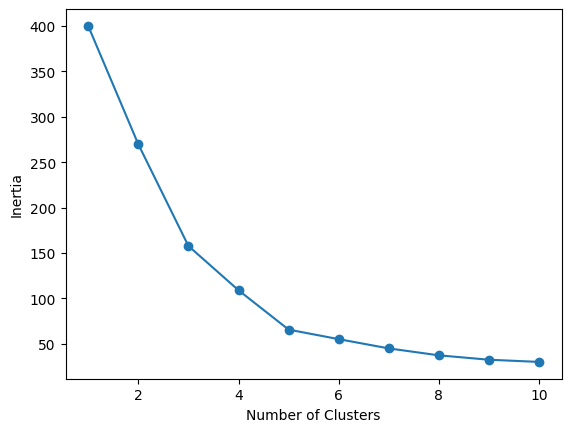

In [29]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(x_scaled)

    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [35]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

kmeans.fit(x_scaled)
df["Cluster"] = kmeans.labels_

df.head()
print(df["Cluster"].value_counts())

Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64


In [36]:
kmeans.cluster_centers_

array([[-0.20091257, -0.02645617],
       [ 0.99158305,  1.23950275],
       [-1.32954532,  1.13217788],
       [ 1.05500302, -1.28443907],
       [-1.30751869, -1.13696536]])

In [37]:
centers = scaler.inverse_transform(
    kmeans.cluster_centers_
)

print(centers)

[[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [26.30434783 20.91304348]]


In [38]:
import joblib

joblib.dump(kmeans, "kmeans_customer_segmentation_model.joblib")
joblib.dump(scaler, "customer_segmentation_scaler.joblib")

['customer_segmentation_scaler.joblib']

In [39]:
loaded_model = joblib.load("kmeans_customer_segmentation_model.joblib")
loaded_scaler = joblib.load("customer_segmentation_scaler.joblib")

sample = [[88, 17]]

sample_scaled = loaded_scaler.transform(sample)

prediction = loaded_model.predict(sample_scaled)

print(prediction)

[3]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
